In [34]:
import matplotlib.pyplot as plt
import torch
import os
import numpy as np
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
from torchvision import datasets, transforms
import copy
from torch import Tensor
import pandas as pd
from scipy.stats import multivariate_normal as normal
from tqdm import tqdm
from PIL import Image

In [35]:
def FedAvg(w):
    w_avg = copy.deepcopy(w[0])
    for k in w_avg.keys():
        for i in range(1, len(w)):
            w_avg[k] += w[i][k]
        w_avg[k] = torch.div(w_avg[k], len(w))
    return w_avg

In [36]:
EPSILON=1e-6
MOMENTUM=0.99
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using {} device".format(device))

Using cuda device


In [37]:
image2 = Image.open('FSU_wordmark_BW_solid_rgb.png').resize((1321, 757))
im2 = image2.convert('L')
npdata = np.asarray(im2)
data = npdata.copy()
data[data < 255] = 0
data[data >= 255] = 2
data[data == 0] = 1
data[data == 2] = 0
im3 = Image.fromarray(np.uint8(data * 255), 'L')
small = data[0::3, 0::3].copy()
im4 = Image.fromarray(np.uint8(small * 255) , 'L')

In [38]:
'''image = Image.open('FSU.png.webp')
im1 = image.convert('L')
npdata = np.asarray(im1)
data = npdata.copy()
data[data < 255] = 0
data[data >= 255] = 2
data[data == 0] = 1
data[data == 2] = 0
im3 = Image.fromarray(np.uint8(data * 255), 'L')
small = data[0::3, 0::3].copy()
im4 = Image.fromarray(np.uint8(small * 255) , 'L')
width, height = im4.size
im4'''

"image = Image.open('FSU.png.webp')\nim1 = image.convert('L')\nnpdata = np.asarray(im1)\ndata = npdata.copy()\ndata[data < 255] = 0\ndata[data >= 255] = 2\ndata[data == 0] = 1\ndata[data == 2] = 0\nim3 = Image.fromarray(np.uint8(data * 255), 'L')\nsmall = data[0::3, 0::3].copy()\nim4 = Image.fromarray(np.uint8(small * 255) , 'L')\nwidth, height = im4.size\nim4"

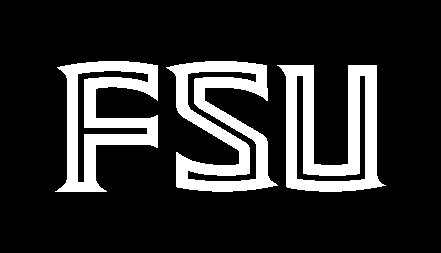

In [39]:
small1 = copy.deepcopy(small)
small1 = copy.deepcopy(small1)
im5 = Image.fromarray(np.uint8(small1 * 255), 'L')
width, height = im5.size
im5

In [40]:
R, C = np.mgrid[:width, :height]
out = np.column_stack((C.ravel(), R.ravel(), small.ravel()))
out = out.astype(np.float32)
input = out[:, 0: 2]
output = out[:, 2]
if type(input) == np.ndarray:
    XX=torch.tensor(input,requires_grad=True)

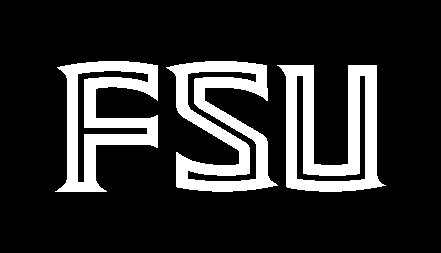

In [41]:
Image.fromarray(np.uint8(small) * 255, 'L')

In [42]:
class NN_test(nn.Module):
    def __init__(self, cin, cout):
        super(NN_test, self).__init__()
        self.cin = cin
        self.cout = cout
        self.project_0 = Dense(self.cin, 16, activate = False)
        self.layer1 = Dense(16, 32)
        self.layer2 = Dense(32, 16)
        self.project_end = Dense(16, self.cout, activate = False)

    def forward(self, X):
        x = self.project_0(X)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.project_end(x)
        return x

In [43]:
out1 = []
for i in range(small1.shape[0]):
    for j in range(small1.shape[1]):
        out1.append([i, j, small1[i, j]])
out1 = np.array(out1).astype(np.float32)

In [44]:
input1 = out1[:, :2]
output1 = out1[:, 2]
if type(input1) == np.ndarray:
    XX1 = torch.tensor(input1, requires_grad = True)

In [45]:
class Config(object):
    Ntime=4 ## There are four snn parts 
    
    #dim=64
    dim = 16
    
    x_dim=2; 
    y_dim=1; 
    
    logging_frequency = 100
    verbose = True
    y_init_range = [0, 1]
    
    #num_hiddens = [dim,256, dim] ## this is for each sub module
    num_hiddens = [dim, 32, dim]
    
def get_config(name):
    try:
        return globals()[name]
    except KeyError:
        raise KeyError("config not defined.")

cfg=get_config("Config")

In [46]:
class Dense(nn.Module):
    def __init__(self, cin, cout, batch_norm = False, activate = True):
        super(Dense, self).__init__()
        self.cin = cin
        self.cout = cout
        self.activate = activate
        self.linear = nn.Linear(self.cin, self.cout)

        if batch_norm: 
            self.bn = nn.BatchNorm1d(cout, eps = EPSILON, momentum = MOMENTUM)
        else:
            self.bn = None

    def forward(self, X):
        x = self.linear(X)
        if self.bn is not None:
            x = self.bn(x)
        if self.activate:
            x = torch.relu(x)
        return x

class FClayerDrift(nn.Module):
    def __init__(self, config, batch_norm = False):
        super(FClayerDrift, self).__init__()
        self.bn = nn.BatchNorm1d(config.num_hiddens[0], eps = EPSILON, momentum = MOMENTUM)

        self.layers = [Dense(config.num_hiddens[i - 1], config.num_hiddens[i]) for i in range(1, len(config.num_hiddens) - 1)]
        self.layers += [Dense(config.num_hiddens[-2], config.num_hiddens[-1], activate = False)]
        self.layers = nn.Sequential(*self.layers)

    def forwardX(self, X):
        #x = self.bn(X)
        x = self.layers(X)
        return x

In [47]:
class Dense2(nn.Module):
    def __init__(self, cin, cout, batch_norm = False, activate = True):
        super(Dense2, self).__init__()
        self.cin = cin
        self.cout = cout
        self.activate = activate
        self.linear = nn.Linear(self.cin, self.cout)

        if batch_norm:
            self.bn=nn.BatchNorm1d(cout,eps=EPSILON,momentum=MOMENTUM)
        else:
            self.bn=None
        
    def forward(self, x):
        x=self.linear(x)
        if self.bn is not None: 
            x=self.bn(x)
        if self.activate:
            x=torch.relu(x)
        return x

class FClayerDiffusion(nn.Module):
    def __init__(self, config, batch_norm = False):
        super(FClayerDiffusion, self).__init__()

        self.bn=nn.BatchNorm1d(config.num_hiddens[0],eps=EPSILON,momentum=MOMENTUM)
        self.layers=[Dense2(config.num_hiddens[i-1],config.num_hiddens[i]) for i in range(1, len(config.num_hiddens)-1)]
        self.layers+=[Dense2(config.num_hiddens[-2], config.num_hiddens[-1],activate=False)]
        self.layers=nn.Sequential(*self.layers)

    def forwardX(self, X):
        x = self.bn(X)
        x = self.layers(X)
        return torch.sigmoid(x)

In [48]:
loss_fn = nn.MSELoss(reduction = 'mean')
class SNN(nn.Module):
    def __init__(self, config, X, y, batch_size):
        super(SNN, self).__init__()
        self.config = config
        self.X = X
        self.driftList = nn.ModuleList([FClayerDrift(self.config) for _ in range(self.config.Ntime)])
        self.diffusionList=nn.ModuleList([FClayerDiffusion(self.config) for _ in range(self.config.Ntime)])
 
        self.project0=Dense(self.config.x_dim,self.config.dim,activate=False)
        self.project_end=Dense(self.config.dim, self.config.y_dim, activate=False)

        self.batch_size = batch_size
        self.h = 1.0 / self.config.Ntime
        self.sqrth = np.sqrt(self.h)
        self.W_p=[torch.tensor(np.random.normal(0,1, (self.X.shape[0],self.config.dim)),dtype=torch.float32, requires_grad=False).to(device) 
                  for i in range(0,self.config.Ntime)]
        self.y = torch.from_numpy(y).unsqueeze(1)

    def forwardX(self, x, idx):
        xMat = []
        xMat.append(x)
        x = self.project0(x)
        xMat.append(x)
        for i in range(0, self.config.Ntime):
            x = x + self.driftList[i].forwardX(x) * self.h + self.diffusionList[i].forwardX(x) * self.W_p[i][idx, :] * self.sqrth
            xMat.append(x)

        x = self.project_end(x)
        xMat.append(x)
        return xMat

    def backwardYZ(self, xMat, idx):
        yMat = []
        zMat = []

        x_terminal = xMat[-1]
        loss = loss_fn(x_terminal, self.y[idx, :].to(device))

        y_terminal = torch.autograd.grad(outputs = [loss], inputs = [x_terminal], grad_outputs = torch.ones_like(loss), 
                                         allow_unused = True, retain_graph = True, create_graph = True)[0]
        yMat.append(y_terminal)
        xin = xMat[-2]
        hami = torch.sum(yMat[-1].detach() * self.project_end(xin), dim = 1)
        ytemp = torch.autograd.grad(outputs = [hami], inputs = [xin], grad_outputs = torch.ones_like(hami), 
                                    allow_unused = True, retain_graph = True, create_graph = True)[0]
        yMat.append(ytemp)

        for i in range(self.config.Ntime - 1, -1, -1):
            xin = xMat[i + 1]
            ztemp = yMat[-1] * self.W_p[i][idx, :] / self.sqrth
            zMat.append(ztemp)

            hami = torch.sum(yMat[-1].detach() * self.driftList[i].forwardX(xin) + ztemp.detach() * self.diffusionList[i].forwardX(xin), dim = 1)
            hami_x = torch.autograd.grad(outputs = [hami], inputs = [xin], grad_outputs = torch.ones_like(hami), 
                                         allow_unused = True, retain_graph = True, create_graph = True)[0]
            ytemp = yMat[-1] + hami_x * self.h
            yMat.append(ytemp)

        xin = xMat[0]
        hami = torch.sum(yMat[-1].detach() * self.project0(xin), dim = 1)
        hami_x = torch.autograd.grad(outputs = [hami], inputs = [xin], grad_outputs = torch.ones_like(hami), 
                                     allow_unused = True, retain_graph = True, create_graph = True)[0]
        ytemp = hami_x
        yMat.append(ytemp)
        return yMat, zMat

    def Hamcompute(self, xMat, yMat, zMat):
        total_ham = 0.0
        ham = torch.sum(yMat[-2].detach() * self.project0(xMat[0].detach()))
        total_ham += ham

        for i in range(0, self.config.Ntime):
            ham = torch.sum(yMat[self.config.Ntime - 1].detach() * self.driftList[i].forwardX(xMat[i + 1].detach()) + zMat[i].detach() * self.diffusionList[i].forwardX(xMat[i + 1].detach()))
            total_ham += ham

        ham = torch.sum(yMat[0].detach() * self.project_end(xMat[-2].detach()))
        total_ham += ham
        return total_ham / self.batch_size

    def predict(self, X):
        xx = X.clone()
        x = self.project0(xx)
        for i in range(0, self.config.Ntime):
            x = x + self.driftList[i].forwardX(x) * self.h + self.diffusionList[i].forwardX(x) * torch.FloatTensor(normal.rvs(size = [x.shape[0], self.config.dim])).to(device) * self.sqrth
        x = self.project_end(x)
        return x
        
    def predict_drift(self, X):
        xx = X.clone()
        x = self.project0(xx)
        for i in range(0, self.config.Ntime):
            x = x + self.driftList[i].forwardX(x) * self.h
        x = self.project_end(x)
        return x

In [49]:
def training(model, X):
    optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4, weight_decay = 1e-8)
    #for e in tqdm(range(epoch)):
    for e in range(epoch):
        optimizer.zero_grad()
        indices = np.random.randint(0, X.shape[0], size = batch_size)
        batch_x = X[indices, :].to(device)

        xmat = model.forwardX(batch_x, indices)
        ymat, zmat = model.backwardYZ(xmat, indices)
        loss_temp = model.Hamcompute(xmat, ymat, zmat)
        loss_temp.backward()
        optimizer.step()
    return model

In [50]:
batch_size = 256
setter = 1
model = SNN(cfg, XX1, output1, batch_size).to(device)
epoch = 5000

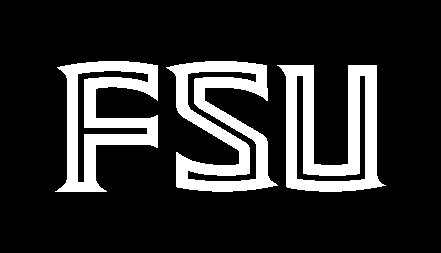

In [51]:
Image.fromarray(np.uint8(small1) * 255, 'L')

158


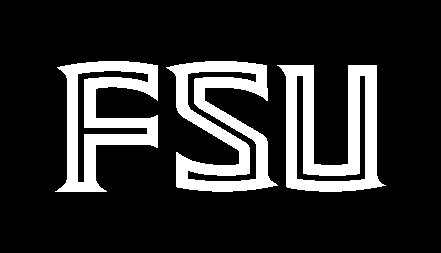

In [63]:
for i in range(139, small1.shape[1]):
    if False not in (small1[:, i] == np.zeros(small1.shape[0])):
        print(i)
        break
small2 = copy.deepcopy(small1)
#for i in range(195, 138, -1):
    #small2[:, i + 20] = small2[:, i]
#for i in range(20):
#    small2[:, 257 + i] = np.zeros(small2.shape[0])
Image.fromarray(np.uint8(small2) * 255, 'L')

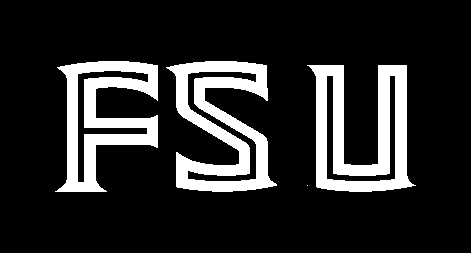

In [64]:
for i in range(30):
    small2 = np.insert(small2, 277, 0, axis = 1)
Image.fromarray(np.uint8(small2) * 255, 'L')

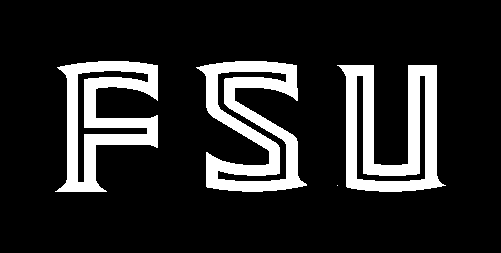

In [65]:
for i in range(30):
    small2 = np.insert(small2, 158, 0, axis = 1)
Image.fromarray(np.uint8(small2) * 255, 'L')

In [66]:
small2.shape

(253, 501)

In [67]:
small2[:, : int(small2.shape[1] / 3)].shape

(253, 167)

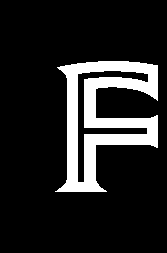

In [68]:
Image.fromarray(np.uint8(small2[:, :int(small2.shape[1] / 3)]) * 255, 'L')#.save('F.png')

In [69]:
small2[:, int(small2.shape[1] / 3): int(small2.shape[1] / 3 * 2)].shape

(253, 167)

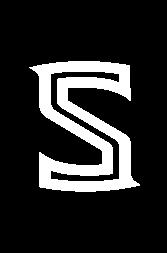

In [70]:
Image.fromarray(np.uint8(small2[:, int(small2.shape[1] / 3): int(small2.shape[1] / 3 * 2)]) * 255, 'L')#.save('S.png')

In [71]:
small2[:, int(small2.shape[1] / 3 * 2): ].shape

(253, 167)

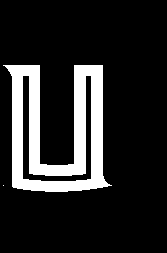

In [72]:
Image.fromarray(np.uint8(small2[:, int(small2.shape[1] / 3 * 2): ]) * 255, 'L')#.save('U.png')

In [73]:
out2 = []
for j in range(small2.shape[1]):
    for i in range(small2.shape[0]):
        out2.append([j, i, small2[i, j]])
out2 = np.array(out2).astype(np.float32)

In [74]:
out2[:, 0] = out2[:, 0] - int(small2.shape[1] / 2)
out2[:, 1] = out2[:, 1] - int(small2.shape[0] / 2)
out2

array([[-250., -126.,    0.],
       [-250., -125.,    0.],
       [-250., -124.,    0.],
       ...,
       [ 250.,  124.,    0.],
       [ 250.,  125.,    0.],
       [ 250.,  126.,    0.]], shape=(126753, 3), dtype=float32)

In [75]:
input2 = out2[:, :2]
output2 = out2[:, 2]
if type(input2) == np.ndarray:
    XX2 = torch.tensor(input2, requires_grad = True)

In [76]:
epoch = 2000
batch_size = 256
setter = 1
model2 = SNN(cfg, XX2, output2, batch_size).to(device)
epoch = 2000
local_size = 2000
sparse_size = 60

In [77]:
temp = SNN(cfg, XX2, output2, batch_size).to(device)
w_global = temp.state_dict()
#w_global = torch.load(os.getcwd() + '/SNN_2d_model/SNN_copy49.pth')
w_local = [copy.deepcopy(w_global) for _ in range(30)]

In [78]:
w_count = {}
for i in range(30):
    w_count[str(i)] = 0

In [79]:
local_set = []
for i in range(30):
    if i < 10: 
        local_set.append(np.concatenate((np.random.choice(range(int(out2.shape[0] / 3)), size = local_size, replace = False), 
                                        np.random.choice(range(int(out2.shape[0] / 3), out2.shape[0]), size = sparse_size, replace = False)), 
                                       axis = None))
    elif i > 19: 
        local_set.append(np.concatenate((np.random.choice(range(int(out2.shape[0] * 2 / 3), out2.shape[0]), size = local_size, replace = False), 
                                         np.random.choice(range(int(out2.shape[0] * 2 / 3)), size = sparse_size, replace = False)), 
                                        axis = None))
    else:
        local_set.append(np.concatenate((np.random.choice(range(int(out2.shape[0] / 3), int(out2.shape[0] * 2 / 3)), size = local_size, replace = False), 
                                         np.random.choice(list(range(int(out2.shape[0] / 3))) + list(range(int(out2.shape[0] * 2 / 3), out2.shape[0])), size = sparse_size, replace = False)), 
                                        axis = None))
    #local_set.append(np.random.randint(0, XX2.shape[0], size = local_size))

In [80]:
for i in range(10):
    print(local_set[10 + i][local_set[10 + i] >= out2.shape[0] / 3][local_set[10 + i][local_set[10 + i] >= out2.shape[0] / 3] < out2.shape[0] * 2 / 3].shape[0])



2000
2000
2000
2000
2000
2000
2000
2000
2000
2000


In [81]:
for i in range(10):
    print(local_set[10 + i][local_set[10 + i] < out2.shape[0] / 3].shape[0] + local_set[10 + i][local_set[10 + i] >= out2.shape[0] * 2 / 3].shape[0])




60
60
60
60
60
60
60
60
60
60


In [84]:
(XX2[local_set[29]][:, 0] < 357 * 1 / 3).sum()

tensor(478)

In [85]:
def training(model, X):
    optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4, weight_decay = 1e-8)
    #for e in tqdm(range(epoch)):
    for e in range(epoch):
        optimizer.zero_grad()
        indices = np.random.randint(0, X.shape[0], size = batch_size)
        batch_x = X[indices, :].to(device)

        xmat = model.forwardX(batch_x, indices)
        ymat, zmat = model.backwardYZ(xmat, indices)
        loss_temp = model.Hamcompute(xmat, ymat, zmat)
        loss_temp.backward()
        optimizer.step()
    return model

In [86]:
for i in tqdm(range(100)):
    idxs_users = np.random.choice(range(30), 5, replace = False)
    temp_model = []
    for idx in idxs_users:
        w_count[str(idx)] = w_count[str(idx)] + 1
        XX3 = XX2[local_set[idx], :]
        output3 = output2[local_set[idx]]
        temp = SNN(cfg, XX3, output3, batch_size).to(device)
        temp.load_state_dict(w_local[idx])
        temp = training(temp, XX3)
        temp_model.append(copy.deepcopy(temp.state_dict()))
    w_global = FedAvg(temp_model)
    j = 0
    for j in range(len(w_local)):
        w_local[j] = copy.deepcopy(w_global)

  1%|          | 1/100 [03:42<6:07:36, 222.79s/it]


KeyboardInterrupt: 

In [ ]:
model1 = SNN(cfg, XX2, output2, batch_size).to(device)
model1.load_state_dict(torch.load(os.getcwd() + '/SNN_copy48_new_1.pth'))

In [ ]:
XX4 = XX2.to(device)
vt = model1.predict(XX4).cpu().detach().numpy()
mid = np.sort(vt.flatten())[small2[small2 == 0].size]
if mid >= 0:
    vt[vt < mid] = 0
    vt[vt >= mid] = 255
else:
    vt[vt >= mid] = 255
    vt[vt < mid] = 0
mid

In [ ]:
Image.fromarray(np.int8(vt.reshape((small2.shape[1], small2.shape[0]))).T, "L")